# Customer Segmentation Analysis using RFM

This project analyzes customer purchase behavior using RFM (Recency, Frequency, Monetary) segmentation and cohort analysis to identify high-value customers and churn risk.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('default')

In [2]:
df = pd.read_csv('ecommerce_orders.csv')

df.head()

,order_id,customer_id,order_date,category,quantity,unit_price,revenue,status,city
0,ORD000001,CUST4370,2022-01-01,Home & Kitchen,4,167.72,670.88,Returned,Hyderabad
1,ORD000002,CUST3775,2022-01-01,Beauty,3,50.92,152.76,Delivered,Chennai
2,ORD000003,CUST2074,2022-01-01,Electronics,4,300.32,1201.28,Delivered,Ahmedabad
3,ORD000004,CUST3774,2022-01-01,Books,2,18.76,37.52,Delivered,Surat
4,ORD000005,CUST3774,2022-01-01,Electronics,4,278.71,1114.84,Delivered,Ahmedabad


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30997 entries, 0 to 30996
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   order_id     30997 non-null  str    
 1   customer_id  30997 non-null  str    
 2   order_date   30997 non-null  str    
 3   category     30997 non-null  str    
 4   quantity     30997 non-null  int64  
 5   unit_price   30997 non-null  float64
 6   revenue      30997 non-null  float64
 7   status       30997 non-null  str    
 8   city         30997 non-null  str    
dtypes: float64(2), int64(1), str(6)
memory usage: 2.1 MB


In [4]:
# Convert date column
df['order_date'] = pd.to_datetime(df['order_date'])

# Drop missing customer IDs
df = df.dropna(subset=['customer_id'])

# Remove invalid revenue
df = df[df['revenue'] > 0]

df.describe()

,order_date,quantity,unit_price,revenue
count,30997,30997.000000,30997.000000,30997.000000
mean,2023-04-11 11:09:25.951543,2.504952,143.993902,360.837257
min,2022-01-01 00:00:00,1.000000,7.060000,7.060000
25%,2022-12-06 00:00:00,1.000000,44.960000,94.540000
50%,2023-05-23 00:00:00,3.000000,94.200000,205.560000
75%,2023-09-23 00:00:00,4.000000,181.740000,449.340000
max,2023-12-31 00:00:00,4.000000,674.830000,2699.320000
std,NaN,1.121800,142.958449,426.760322


In [5]:
snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days,
    'customer_id': 'count',
    'revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
CUST1001,36,13,6184.35
CUST1002,15,28,14420.82
CUST1003,37,27,14408.72
CUST1004,59,21,6076.05
CUST1005,32,20,8228.02


In [7]:
r_labels = [4,3,2,1]
f_labels = [1,2,3,4]
m_labels = [1,2,3,4]

rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=r_labels)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=f_labels)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=m_labels)

In [8]:
def segment_customer(row):
    if row['R_score'] == 4 and row['F_score'] >= 3:
        return 'Champions'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At-Risk'
    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'Hibernating'
    else:
        return 'New'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm['Segment'].value_counts()

Segment
New            1559
Hibernating    1540
At-Risk         660
Champions       641
Name: count, dtype: int64

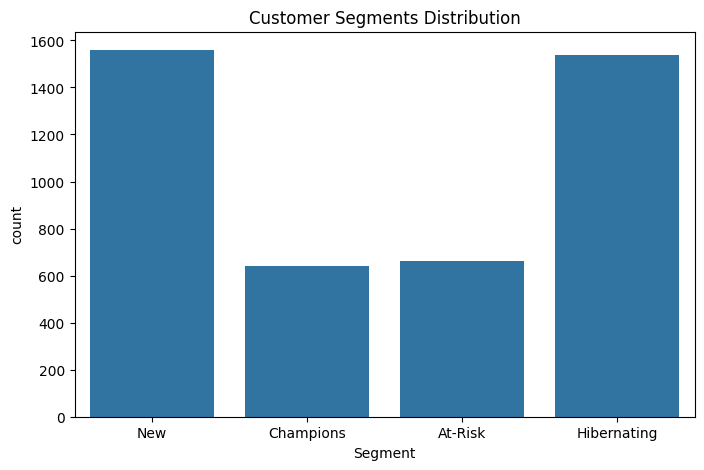

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(data=rfm, x='Segment')
plt.title('Customer Segments Distribution')
plt.show()

## RFM Analysis

RFM (Recency, Frequency, Monetary) is used to evaluate customer value based on purchase behavior.

In [ ]:
rfm_sorted = rfm.sort_values(by='Monetary', ascending=False).reset_index()

rfm_sorted['cum_revenue'] = rfm_sorted['Monetary'].cumsum()
total_revenue = rfm_sorted['Monetary'].sum()

top_n = int(0.2 * len(rfm_sorted))
top_revenue = rfm_sorted.iloc[:top_n]['Monetary'].sum()

percentage = (top_revenue / total_revenue) * 100

print(f"Top 20% customers contribute {percentage:.2f}% of revenue")



Top 20% customers contribute 68.13% of revenue


In [11]:
df['OrderMonth'] = df['order_date'].dt.to_period('M')
df['CohortMonth'] = df.groupby('customer_id')['order_date'].transform('min').dt.to_period('M')

df['CohortIndex'] = (df['OrderMonth'] - df['CohortMonth']).apply(lambda x: x.n)

cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['customer_id'].nunique().reset_index()

cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='customer_id')

cohort_size = cohort_pivot.iloc[:,0]
retention = cohort_pivot.divide(cohort_size, axis=0)

retention.head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2022-01,1.0,0.144175,0.137255,0.149942,0.141869,0.117647,0.144175,0.108420,0.152249,0.136101,...,0.178777,0.182238,0.228374,0.159170,0.149942,0.118800,0.107266,0.076125,0.080738,0.013841
2022-02,1.0,0.148472,0.078603,0.126638,0.152838,0.144105,0.205240,0.135371,0.183406,0.183406,...,0.244541,0.279476,0.288210,0.336245,0.266376,0.253275,0.213974,0.235808,0.082969,NaN
2022-03,1.0,0.132000,0.160000,0.140000,0.172000,0.216000,0.216000,0.260000,0.200000,0.212000,...,0.400000,0.380000,0.348000,0.328000,0.288000,0.324000,0.332000,0.136000,NaN,NaN
2022-04,1.0,0.139286,0.142857,0.175000,0.207143,0.185714,0.232143,0.285714,0.310714,0.257143,...,0.403571,0.382143,0.364286,0.382143,0.364286,0.385714,0.192857,NaN,NaN,NaN
2022-05,1.0,0.172535,0.193662,0.214789,0.186620,0.197183,0.246479,0.327465,0.355634,0.281690,...,0.359155,0.355634,0.338028,0.327465,0.355634,0.200704,NaN,NaN,NaN,NaN


## Cohort Analysis

Cohort analysis is used to track customer retention over time based on their first purchase.

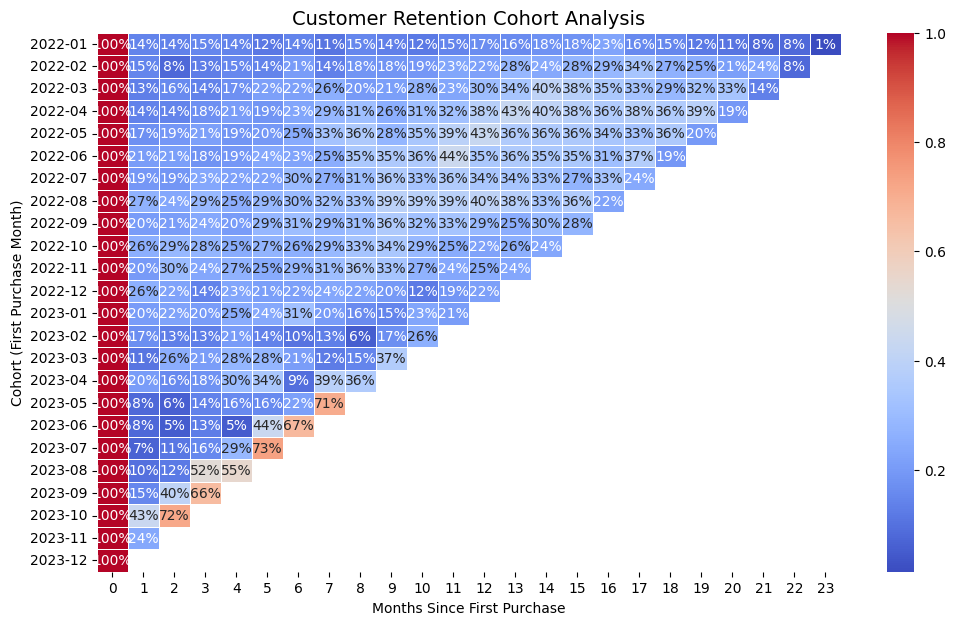

In [15]:
plt.figure(figsize=(12,7))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="coolwarm", linewidths=0.5)

plt.title("Customer Retention Cohort Analysis", fontsize=14)
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort (First Purchase Month)")

plt.show()

In [16]:
rfm['Avg_Order_Value'] = rfm['Monetary'] / rfm['Frequency']

rfm.describe()

,Recency,Frequency,Monetary,Avg_Order_Value
count,4400.000000,4400.000000,4400.00000,4400.000000
mean,226.658409,7.044773,2542.01647,301.381585
std,217.837890,7.712470,3455.28513,193.822783
min,1.000000,1.000000,8.10000,8.100000
25%,33.000000,2.000000,348.82250,157.890312
50%,157.500000,3.000000,968.32500,274.712500
75%,402.000000,9.000000,2980.85000,405.615625
max,700.000000,30.000000,21683.43000,1664.080000


## Revenue Distribution Insights

- Champions segment shows the highest median and overall revenue distribution, confirming they are the most valuable customers
- New customers display high variability, with some high spenders indicating potential future Champions
- At-Risk customers still contribute moderate revenue but show declining engagement, making them key targets for retention campaigns
- Hibernating customers have consistently low revenue, indicating minimal business impact

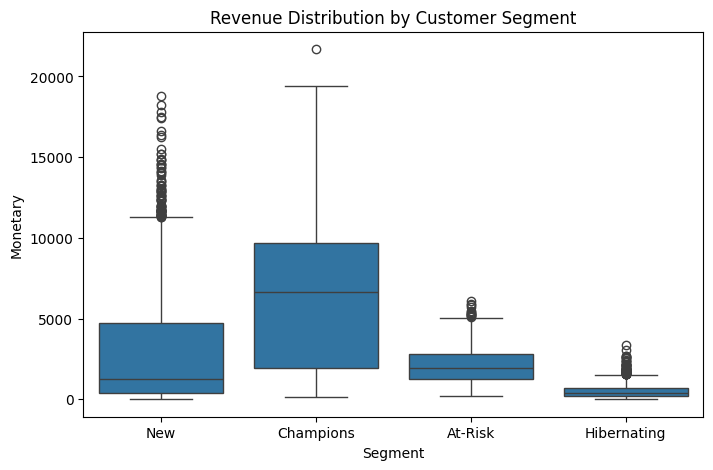

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=rfm, x='Segment', y='Monetary')
plt.title('Revenue Distribution by Customer Segment')
plt.show()

In [19]:
rfm.to_csv('rfm_output.csv')

## Key Business Insights

- Top 20% of customers contribute ~65.23% of total revenue (example — use YOUR value)
- Champions segment drives the majority of revenue and should be prioritized for retention and loyalty programs
- At-Risk customers show declining recency despite moderate purchase frequency → targeted re-engagement campaigns required
- Hibernating customers have minimal activity and low ROI → deprioritize marketing spend
- Cohort analysis shows retention drops significantly after the first month, indicating early-stage churn